# Performance Plots
This Jupyter notebook contains the code used to generate the plots used in the report.

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Common Courses

In [115]:
# load csv file containing results of the common courses query
df = pd.read_csv('performance/database_query_times_common_courses.csv', delimiter=";")
df[20:]

,Query,Database Type,Hour of the day,Time in ms,Run ID
20,Common courses,Graph database,10,232,1
21,Common courses,Graph database,10,40,2
22,Common courses,Graph database,10,25,3
23,Common courses,Graph database,10,37,4
24,Common courses,Graph database,10,26,5
25,Common courses,Graph database,10,28,6
26,Common courses,Graph database,10,43,7
27,Common courses,Graph database,10,25,8
28,Common courses,Graph database,10,26,9
29,Common courses,Graph database,10,25,10


In [116]:
# delete entry of first run (cold run)
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

df_cleaned = df[~condition]

df_cleaned

,Query,Database Type,Hour of the day,Time in ms,Run ID
0,Common courses,Relational Database,13,5,1
1,Common courses,Relational Database,13,6,2
2,Common courses,Relational Database,13,6,3
3,Common courses,Relational Database,13,6,4
4,Common courses,Relational Database,13,7,5
...,...,...,...,...,...
75,Common courses,Graph database,21,27,6
76,Common courses,Graph database,21,27,7
77,Common courses,Graph database,21,26,8
78,Common courses,Graph database,21,24,9


In [117]:
# Calculate average execution times by database type and hour
df_avg = df_cleaned.groupby(['Database Type', 'Hour of the day'])['Time in ms'].mean().reset_index()
df_avg

,Database Type,Hour of the day,Time in ms
0,Graph database,10,30.555556
1,Graph database,13,33.333333
2,Graph database,16,30.777778
3,Graph database,18,27.333333
4,Graph database,20,28.222222
5,Graph database,21,25.555556
6,Relational Database,10,5.900000
7,Relational Database,13,5.900000


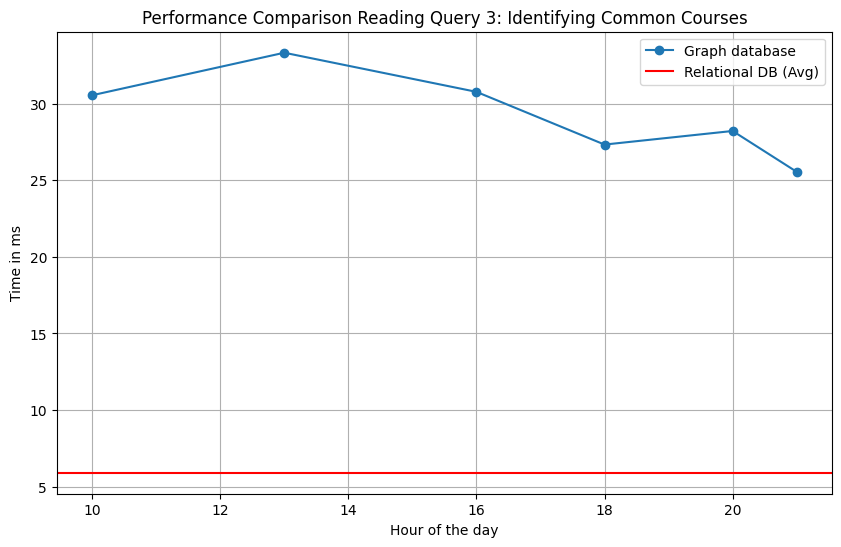

In [118]:
df_pivot = df_avg.pivot(index='Hour of the day', columns='Database Type', values='Time in ms')

# Plotten
plt.figure(figsize=(10, 6))
for column in df_pivot.columns:
    if column != "Relational Database":
        plt.plot(df_pivot.index, df_pivot[column], marker='o', label=column)

# Average time for the relational database over all hours
relational_avg = df_avg[df_avg['Database Type'] == 'Relational Database']['Time in ms'].mean()

# Add horizontal line for the average value of the relational database
plt.axhline(y=relational_avg, color='r', linestyle='-', label='Relational DB (Avg)')


plt.title('Performance Comparison Reading Query 3: Identifying Common Courses')
plt.xlabel('Hour of the day')
plt.ylabel('Time in ms')
plt.legend()
plt.grid(True)
# save as png
plt.savefig('performance/performance_common_courses.png')
plt.show()

In [119]:

def create_plot(title, path_png, df_avg):
    df_pivot = df_avg.pivot(index='Hour of the day', columns='Database Type', values='Time in ms')
    
    # Plotten
    plt.figure(figsize=(10, 6))
    for column in df_pivot.columns:
        if column != "Relational Database":
            plt.plot(df_pivot.index, df_pivot[column], marker='o', label=column)
    
    relational_avg = df_avg[df_avg['Database Type'] == 'Relational Database']['Time in ms'].mean()
    
    plt.axhline(y=relational_avg, color='r', linestyle='-', label='Relational DB (Avg)')
    
    
    plt.title(title)
    plt.xlabel('Hour of the day')
    plt.ylabel('Time in ms')
    plt.legend()
    plt.grid(True)
    plt.savefig(path_png)
    plt.show()

## Recommendations Query

In [120]:
df = pd.read_csv('performance/recommendations_query_times.csv', delimiter=";")
df

,Query,Database Type,Hour of the day,Time in ms,Run ID
0,Recommendations,Relational Database,10,170,1
1,Recommendations,Relational Database,10,76,2
2,Recommendations,Relational Database,10,65,3
3,Recommendations,Relational Database,10,61,4
4,Recommendations,Relational Database,10,62,5
...,...,...,...,...,...
65,Recommendations,Graph database,21,6,6
66,Recommendations,Graph database,21,5,7
67,Recommendations,Graph database,21,5,8
68,Recommendations,Graph database,21,6,9


In [121]:
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

df_cleaned = df[~condition]
df_avg = df_cleaned.groupby(['Database Type', 'Hour of the day'])['Time in ms'].mean().reset_index()
df_avg

,Database Type,Hour of the day,Time in ms
0,Graph database,10,38.000000
1,Graph database,13,9.666667
2,Graph database,16,5.777778
3,Graph database,18,6.111111
4,Graph database,20,5.888889
5,Graph database,21,5.888889
6,Relational Database,10,73.900000


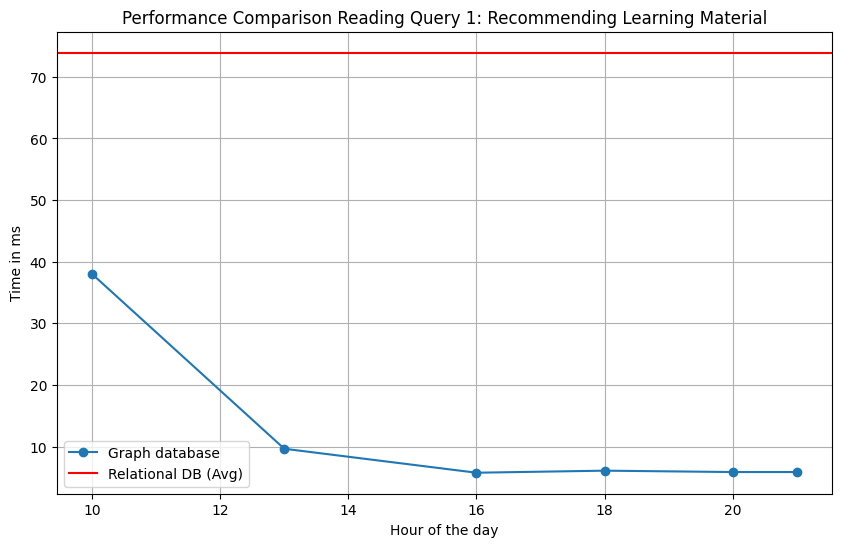

In [122]:
create_plot('Performance Comparison Reading Query 1: Recommending Learning Material', 'performance/performance_recommendations.png', df_avg)

## Risk students query

In [123]:
df = pd.read_csv('performance/risk_students_performance.csv', delimiter=";")
df

,Query,Database Type,Hour of the day,Time in ms,Run ID
0,Risk students,Relational Database,13,74,1
1,Risk students,Relational Database,13,95,2
2,Risk students,Relational Database,13,92,3
3,Risk students,Relational Database,13,94,4
4,Risk students,Relational Database,13,90,5
...,...,...,...,...,...
65,Graph datenbank,Graph Database,21,9,6
66,Graph datenbank,Graph Database,21,10,7
67,Graph datenbank,Graph Database,21,8,8
68,Graph datenbank,Graph Database,21,7,9


In [124]:
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

df_cleaned = df[~condition]
df_avg = df_cleaned.groupby(['Database Type', 'Hour of the day'])['Time in ms'].mean().reset_index()
df_avg

,Database Type,Hour of the day,Time in ms
0,Graph Database,10,27.6
1,Graph Database,13,13.8
2,Graph Database,16,39.2
3,Graph Database,18,11.7
4,Graph Database,20,12.2
5,Graph Database,21,15.3
6,Relational Database,13,90.9


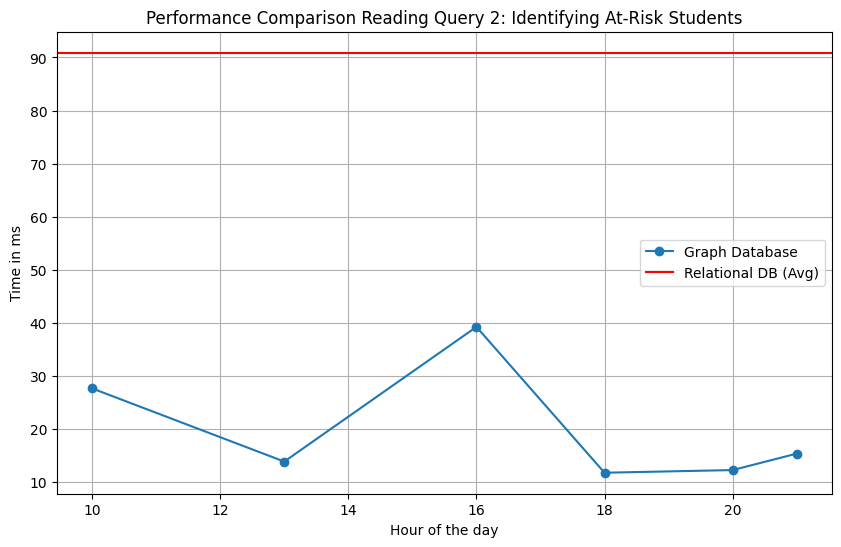

In [125]:
create_plot('Performance Comparison Reading Query 2: Identifying At-Risk Students', 'performance/performance_risk_students.png', df_avg)

## Insert Query

In [126]:
df = pd.read_csv('performance/insert_performance.csv', delimiter=";")
df

,Query,Database Type,Hour of the day,Time in ms,Run ID
0,Insert,Relational Database,10,4,1
1,Insert,Relational Database,10,3,2
2,Insert,Relational Database,10,3,3
3,Insert,Relational Database,10,4,4
4,Insert,Relational Database,10,3,5
...,...,...,...,...,...
67,Insert,Graph Database,21,10,6
68,Insert,Graph Database,21,10,7
69,Insert,Graph Database,21,11,8
70,Insert,Graph Database,21,11,9


In [127]:
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

df_cleaned = df[~condition]
# Durchschnittliche Ausführungszeiten nach Datenbanktyp und Stunde berechnen
df_avg = df_cleaned.groupby(['Database Type', 'Hour of the day'])['Time in ms'].mean().reset_index()
df_avg

,Database Type,Hour of the day,Time in ms
0,Graph Database,10,56.916667
1,Graph Database,13,70.000000
2,Graph Database,16,69.300000
3,Graph Database,18,17.100000
4,Graph Database,20,26.600000
5,Graph Database,21,14.100000
6,Relational Database,10,3.200000


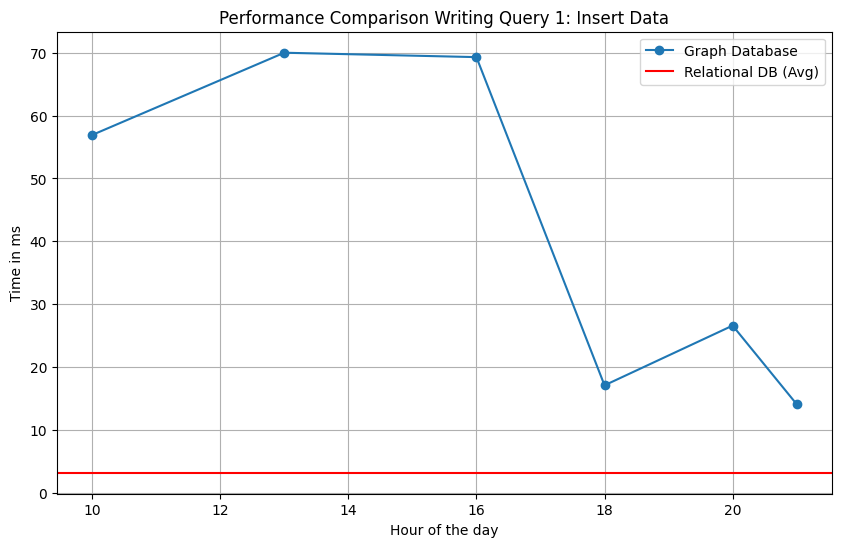

In [128]:
create_plot('Performance Comparison Writing Query 1: Insert Data', 'performance/performance_insert.png', df_avg)

## Students in course Query

In [129]:
df = pd.read_csv('performance/students_in_course_performance.csv', delimiter=";")
df

,Query,Database Type,Hour of the day,Time in ms,Run ID
0,Students in a course,Relational Database,10,1,1
1,Students in a course,Relational Database,10,1,2
2,Students in a course,Relational Database,10,1,3
3,Students in a course,Relational Database,10,1,4
4,Students in a course,Relational Database,10,1,5
...,...,...,...,...,...
65,Students in a course,Graph Database,21,2,6
66,Students in a course,Graph Database,21,3,7
67,Students in a course,Graph Database,21,3,8
68,Students in a course,Graph Database,21,2,9


In [130]:
# Bedingungen für das Löschen festlegen
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

# Zeilen löschen, die die Bedingungen erfüllen
df_cleaned = df[~condition]
# Durchschnittliche Ausführungszeiten nach Datenbanktyp und Stunde berechnen
df_avg = df_cleaned.groupby(['Database Type', 'Hour of the day'])['Time in ms'].mean().reset_index()
df_avg

,Database Type,Hour of the day,Time in ms
0,Graph Database,10,9.1
1,Graph Database,13,15.2
2,Graph Database,16,5.0
3,Graph Database,18,4.8
4,Graph Database,20,15.1
5,Graph Database,21,5.9
6,Relational Database,10,1.1


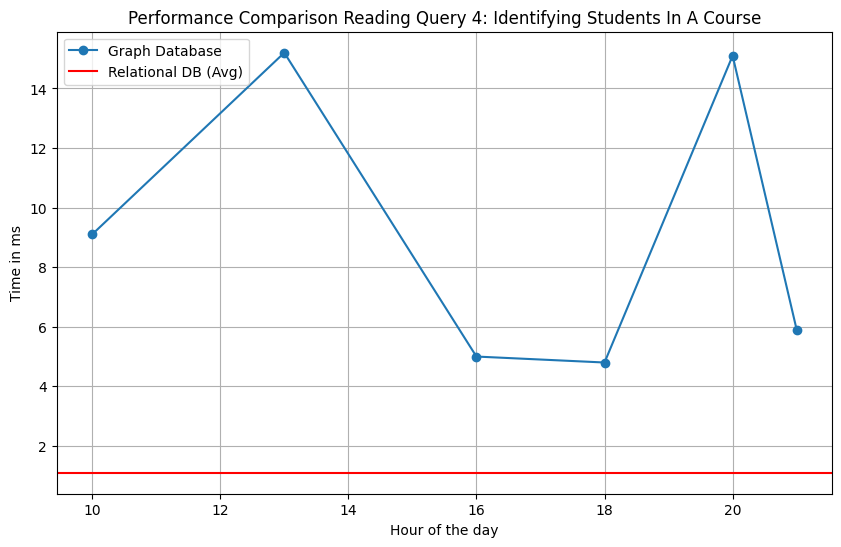

In [131]:
create_plot('Performance Comparison Reading Query 4: Identifying Students In A Course', 'performance/performance_students_in_course.png', df_avg)

# Bar Plots

In [132]:

# Read the CSV file containing database query times for common courses
df = pd.read_csv('performance/database_query_times_common_courses.csv', delimiter=";")

# Define the condition to filter out rows where 'Database Type' is 'Graph database' and 'Run ID' is 1
condition = (df['Database Type'] == 'Graph database') & (df['Run ID'] == 1)

# Filter out the rows matching the condition
df_cleaned = df[~condition]

# Group the cleaned DataFrame by 'Database Type' and calculate the mean query time
df_avg = df_cleaned.groupby(['Database Type'])['Time in ms'].mean().reset_index()

# Display the resulting DataFrame with average query times
df_avg


,Database Type,Time in ms
0,Graph database,29.296296
1,Relational Database,5.900000


In [133]:
# add new Column 'Query'
df_avg['Query'] = 'Common Courses'

df_avg

,Database Type,Time in ms,Query
0,Graph database,29.296296,Common Courses
1,Relational Database,5.900000,Common Courses


In [134]:
# students in a course
df_students_in_course = pd.read_csv('performance/students_in_course_performance.csv', delimiter=";")
condition = (df_students_in_course['Database Type'] == 'Graph database') & (df_students_in_course['Run ID'] == 1)

df_cleaned_students_in_course = df_students_in_course[~condition]

df_avg_students_in_course = df_cleaned_students_in_course.groupby(['Database Type'])['Time in ms'].mean().reset_index()
df_avg_students_in_course

,Database Type,Time in ms
0,Graph Database,9.183333
1,Relational Database,1.100000


In [135]:
df_avg_students_in_course['Query'] = 'Students In Course'
df_avg_students_in_course

,Database Type,Time in ms,Query
0,Graph Database,9.183333,Students In Course
1,Relational Database,1.100000,Students In Course


In [136]:
# recommendations
df_recommendations = pd.read_csv('performance/recommendations_query_times.csv', delimiter=";")
condition = (df_recommendations['Database Type'] == 'Graph database') & (df_recommendations['Run ID'] == 1)

df_cleaned_recommendations = df_recommendations[~condition]

df_avg_recommendations = df_cleaned_recommendations.groupby(['Database Type'])['Time in ms'].mean().reset_index()
df_avg_recommendations

,Database Type,Time in ms
0,Graph database,11.888889
1,Relational Database,73.900000


In [137]:
df_avg_recommendations['Query'] = 'Recommending Learning Materials'
df_avg_recommendations

,Database Type,Time in ms,Query
0,Graph database,11.888889,Recommending Learning Materials
1,Relational Database,73.900000,Recommending Learning Materials


In [138]:
# risk students
df_risk_students = pd.read_csv('performance/risk_students_performance.csv', delimiter=";")
condition = (df_risk_students['Database Type'] == 'Graph database') & (df_risk_students['Run ID'] == 1)

df_cleaned_risk_students = df_risk_students[~condition]

df_avg_risk_students = df_cleaned_risk_students.groupby(['Database Type'])['Time in ms'].mean().reset_index()
df_avg_risk_students

,Database Type,Time in ms
0,Graph Database,19.966667
1,Relational Database,90.900000


In [139]:
df_avg_risk_students['Query'] = 'Risk Students'
df_avg_risk_students

,Database Type,Time in ms,Query
0,Graph Database,19.966667,Risk Students
1,Relational Database,90.900000,Risk Students


In [140]:
# Insert
df_insert = pd.read_csv('performance/insert_performance.csv', delimiter=";")
condition = (df_insert['Database Type'] == 'Graph database') & (df_insert['Run ID'] == 1)

df_cleaned_insert = df_insert[~condition]

df_avg_insert = df_cleaned_insert.groupby(['Database Type'])['Time in ms'].mean().reset_index()
df_avg_insert

,Database Type,Time in ms
0,Graph Database,42.806452
1,Relational Database,3.200000


In [141]:
df_avg_insert['Query'] = 'Insert Data'

df_avg_insert

,Database Type,Time in ms,Query
0,Graph Database,42.806452,Insert Data
1,Relational Database,3.200000,Insert Data


In [142]:
# combine all dataframes to one 
df_combined = pd.concat([df_avg_insert, df_avg_recommendations,df_avg_risk_students, df_avg, df_avg_students_in_course ], ignore_index=True)

df_combined

,Database Type,Time in ms,Query
0,Graph Database,42.806452,Insert Data
1,Relational Database,3.200000,Insert Data
2,Graph database,11.888889,Recommending Learning Materials
3,Relational Database,73.900000,Recommending Learning Materials
4,Graph Database,19.966667,Risk Students
5,Relational Database,90.900000,Risk Students
6,Graph database,29.296296,Common Courses
7,Relational Database,5.900000,Common Courses
8,Graph Database,9.183333,Students In Course
9,Relational Database,1.100000,Students In Course


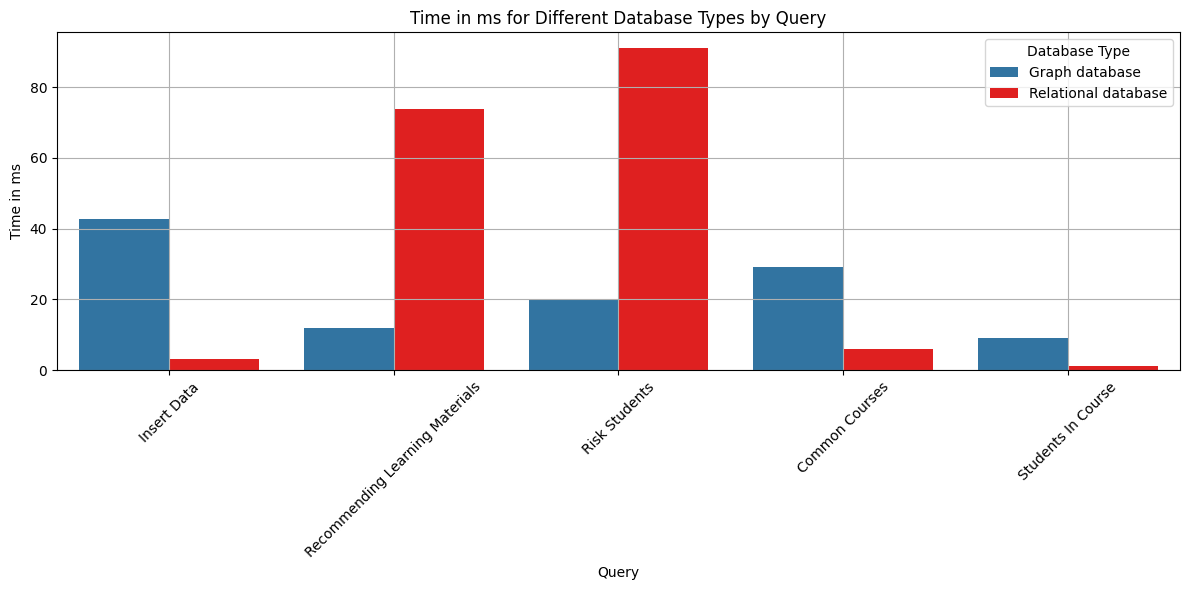

In [143]:

# Ensure the columns are correctly formatted
df_combined['Database Type'] = df_combined['Database Type'].str.strip()
df_combined['Database Type'] = df_combined['Database Type'].str.capitalize()

# Create a barplot
plt.figure(figsize=(12, 6))  # Set the figure size
plt.tight_layout()  # Adjust the layout to fit everything

# Define the color palette for the barplot
palette = {
    'Graph database': '#1f77b4',  # Blue
    'Relational database': 'red'  # Red
}

# Create the barplot using seaborn
sns.barplot(x='Query', y='Time in ms', hue='Database Type', data=df_combined, palette=palette)

# Add plot details
plt.title('Time in ms for Different Database Types by Query')  # Set the title
plt.xlabel('Query')  
plt.ylabel('Time in ms')  
plt.legend(title='Database Type')  
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.grid(True) 
plt.savefig('performance/performance_barplots.png')  # Save the plot as an image file
plt.show()  # Display the plot
